Analyzed 4 datasets from: /home/dataset-assist-0/jiahui/pepbenchmark/final/generation/lm-based/esm-peptide/peptide-esm/pretrain_data
Summary saved to: /home/dataset-assist-0/jiahui/pepbenchmark/final/generation/lm-based/esm-peptide/peptide-esm/assests/dataset_summary.csv
Amino acid distribution saved to: /home/dataset-assist-0/jiahui/pepbenchmark/final/generation/lm-based/esm-peptide/peptide-esm/assests/amino_acid_distribution.csv



,dataset,sequence_count,residue_count,min_length,median_length,mean_length,std_length,p95_length,p99_length,max_length
0,unism,3157531,119912483,1,41,37.98,11.01,50,50,50
1,uniref,2672904,107771785,2,42,40.32,8.74,50,50,50
2,uniref50,1932360,76692615,11,41,39.69,8.68,50,50,50
3,smprot,484627,12140698,1,24,25.05,13.07,47,50,50


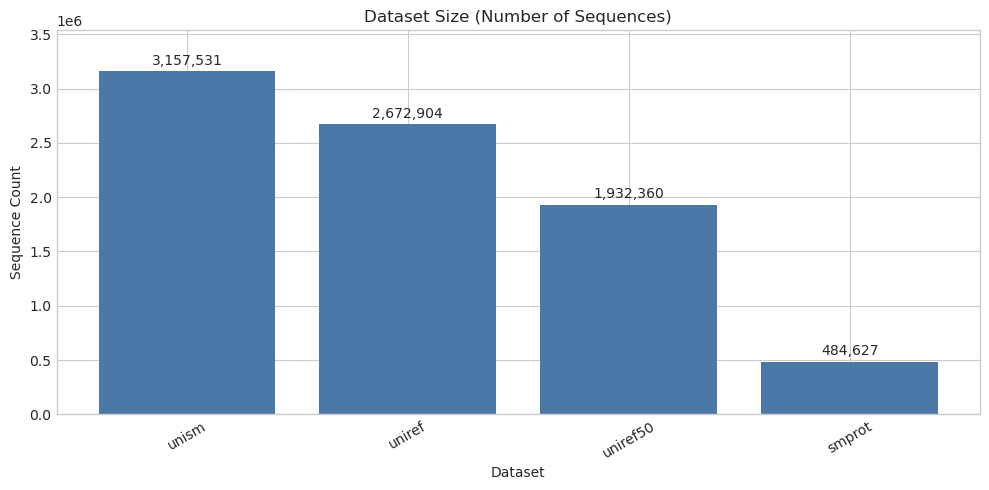

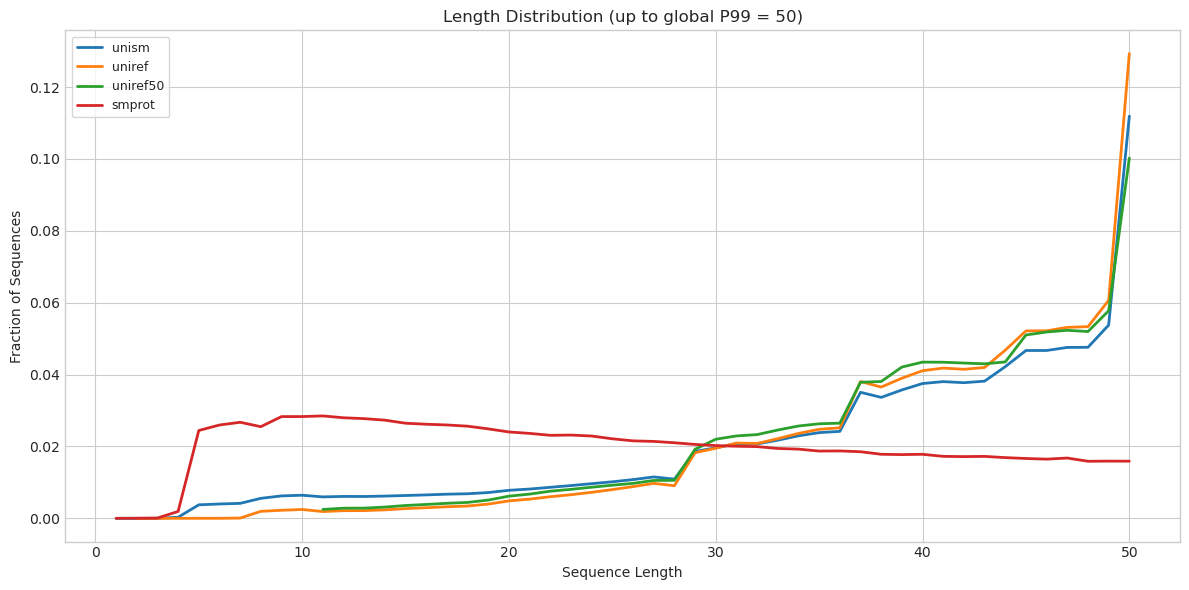

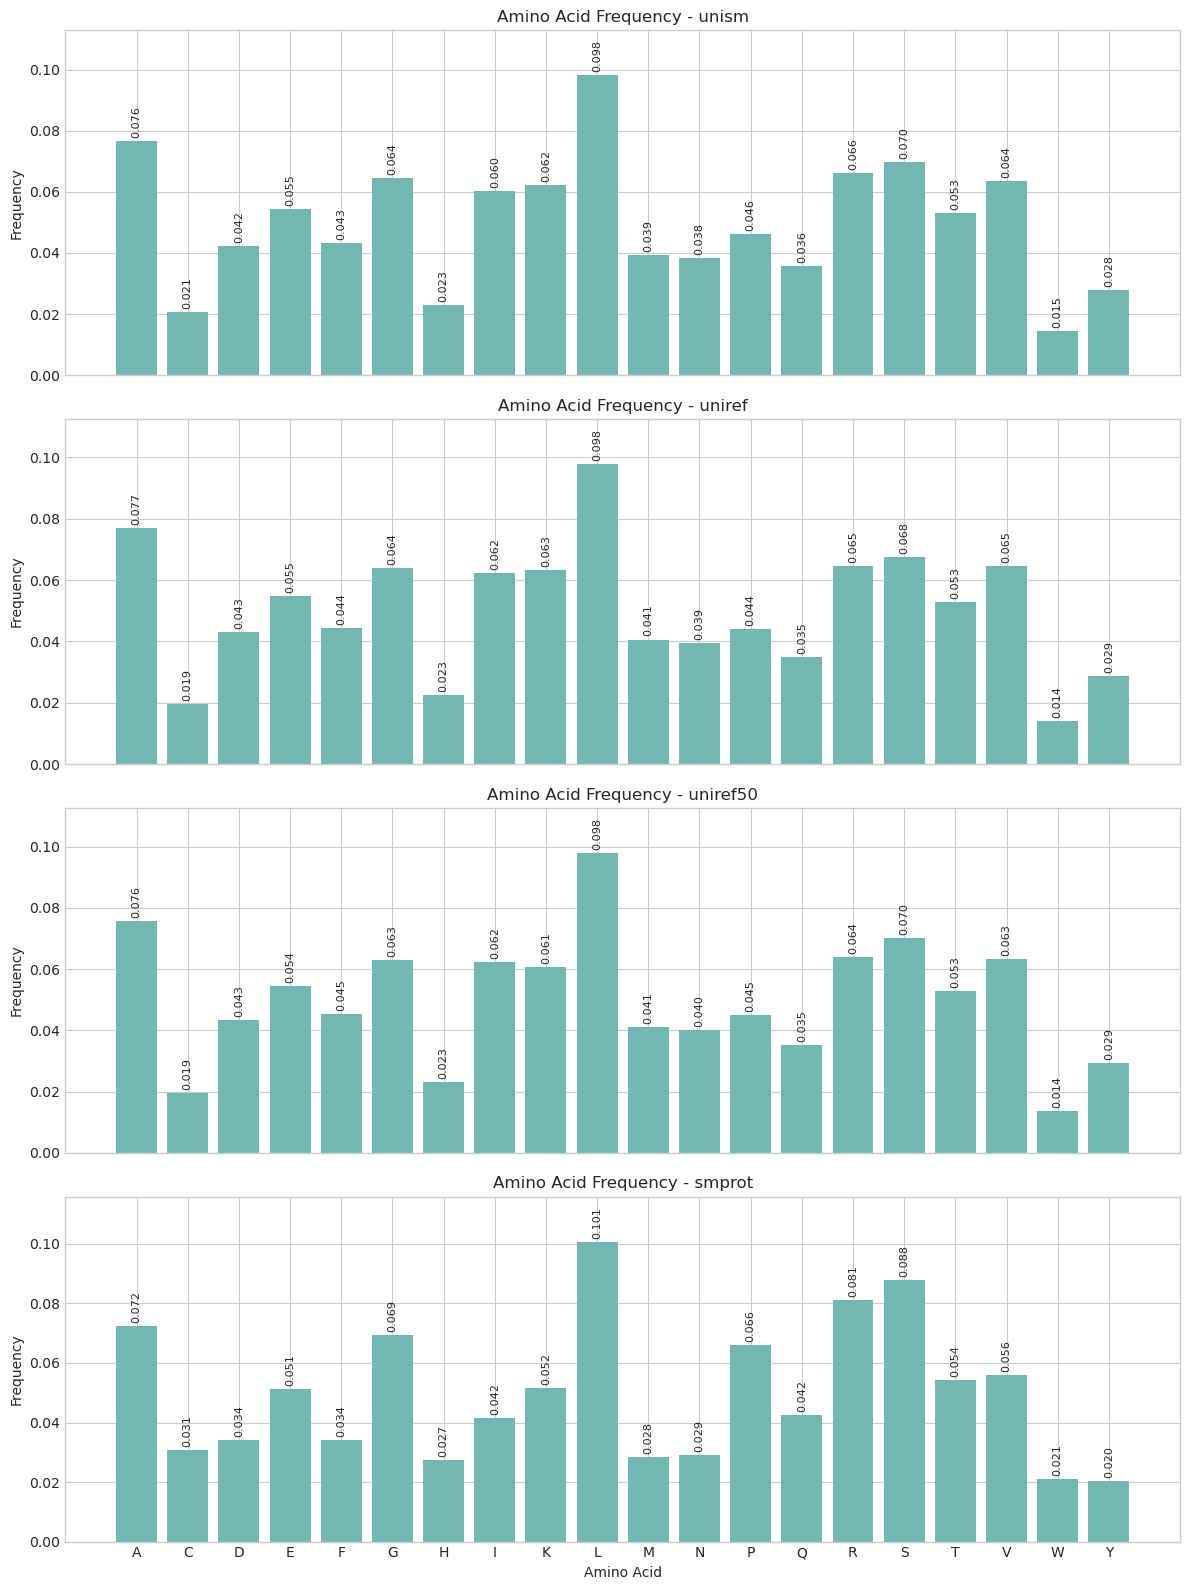

,dataset,sequence_count,residue_count,min_length,median_length,mean_length,std_length,p95_length,p99_length,max_length
0,unism,3157531,119912483,1,41,37.98,11.01,50,50,50
1,uniref,2672904,107771785,2,42,40.32,8.74,50,50,50
2,uniref50,1932360,76692615,11,41,39.69,8.68,50,50,50
3,smprot,484627,12140698,1,24,25.05,13.07,47,50,50


In [19]:
from pathlib import Path
from collections import Counter
import math

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "pretrain_data"
OUTPUT_DIR = BASE_DIR / "assests"
OUTPUT_DIR.mkdir(exist_ok=True)

DATASET_FILES = sorted(DATA_DIR.glob("*.txt"))
if not DATASET_FILES:
    raise FileNotFoundError(f"No .txt files found in {DATA_DIR}")


def quantile_from_counter(counter: Counter, q: float) -> int:
    total = sum(counter.values())
    if total == 0:
        return 0
    target = max(1, math.ceil(total * q))
    cumulative = 0
    for length in sorted(counter):
        cumulative += counter[length]
        if cumulative >= target:
            return length
    return max(counter)


def analyze_dataset(file_path: Path) -> dict:
    sequence_count = 0
    residue_count = 0
    length_sum_sq = 0
    min_length = None
    max_length = 0
    length_counter = Counter()
    aa_counter = Counter()

    with file_path.open("r", encoding="utf-8") as handle:
        for raw_line in handle:
            sequence = raw_line.strip().upper()
            if not sequence:
                continue

            length = len(sequence)
            sequence_count += 1
            residue_count += length
            length_sum_sq += length * length
            min_length = length if min_length is None else min(min_length, length)
            max_length = max(max_length, length)
            length_counter[length] += 1
            aa_counter.update(sequence)

    if sequence_count == 0:
        return {
            "dataset": file_path.stem,
            "file_path": file_path,
            "sequence_count": 0,
            "residue_count": 0,
            "min_length": 0,
            "max_length": 0,
            "mean_length": 0.0,
            "std_length": 0.0,
            "median_length": 0,
            "p95_length": 0,
            "p99_length": 0,
            "length_counter": length_counter,
            "aa_counter": aa_counter,
        }

    mean_length = residue_count / sequence_count
    variance = max(length_sum_sq / sequence_count - mean_length ** 2, 0.0)

    return {
        "dataset": file_path.stem,
        "file_path": file_path,
        "sequence_count": sequence_count,
        "residue_count": residue_count,
        "min_length": min_length,
        "max_length": max_length,
        "mean_length": mean_length,
        "std_length": math.sqrt(variance),
        "median_length": quantile_from_counter(length_counter, 0.5),
        "p95_length": quantile_from_counter(length_counter, 0.95),
        "p99_length": quantile_from_counter(length_counter, 0.99),
        "length_counter": length_counter,
        "aa_counter": aa_counter,
    }


results = [analyze_dataset(file_path) for file_path in DATASET_FILES]
results = sorted(results, key=lambda item: item["sequence_count"], reverse=True)

dataset_names = [item["dataset"] for item in results]
all_amino_acids = sorted({aa for item in results for aa in item["aa_counter"]})

summary_df = pd.DataFrame(
    [
        {
            "dataset": item["dataset"],
            "sequence_count": item["sequence_count"],
            "residue_count": item["residue_count"],
            "min_length": item["min_length"],
            "median_length": item["median_length"],
            "mean_length": round(item["mean_length"], 2),
            "std_length": round(item["std_length"], 2),
            "p95_length": item["p95_length"],
            "p99_length": item["p99_length"],
            "max_length": item["max_length"],
        }
        for item in results
    ]
)

aa_distribution_df = pd.DataFrame(
    {
        item["dataset"]: {
            aa: item["aa_counter"][aa] / max(sum(item["aa_counter"].values()), 1)
            for aa in all_amino_acids
        }
        for item in results
    }
).T.fillna(0.0)

summary_path = OUTPUT_DIR / "dataset_summary.csv"
aa_dist_path = OUTPUT_DIR / "amino_acid_distribution.csv"
summary_df.to_csv(summary_path, index=False)
aa_distribution_df.to_csv(aa_dist_path)

print(f"Analyzed {len(results)} datasets from: {DATA_DIR}")
print(f"Summary saved to: {summary_path}")
print(f"Amino acid distribution saved to: {aa_dist_path}\n")
display(summary_df)

plt.style.use("seaborn-v0_8-whitegrid")

# =========================
# 1) Data size: 柱状图 + 顶部数值标注
# =========================
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(summary_df["dataset"], summary_df["sequence_count"], color="#4C78A8")

ax.set_title("Dataset Size (Number of Sequences)")
ax.set_xlabel("Dataset")
ax.set_ylabel("Sequence Count")
ax.tick_params(axis="x", rotation=30)

max_count = summary_df["sequence_count"].max() if len(summary_df) > 0 else 0
offset = max(max_count * 0.01, 1)

for bar, value in zip(bars, summary_df["sequence_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylim(0, max_count * 1.12 if max_count > 0 else 1)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset_sizes.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# 2) Length distribution
# =========================
max_plot_length = max(item["p99_length"] for item in results)
fig, ax = plt.subplots(figsize=(12, 6))
for item in results:
    lengths = sorted(length for length in item["length_counter"] if length <= max_plot_length)
    probs = [item["length_counter"][length] / item["sequence_count"] for length in lengths]
    ax.plot(lengths, probs, linewidth=2, label=item["dataset"])
ax.set_title(f"Length Distribution (up to global P99 = {max_plot_length})")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Fraction of Sequences")
ax.legend(frameon=True, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "length_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# 3) Amino acid frequency: 改为每个数据集一个柱状图子图
# =========================
n_datasets = len(results)
fig_height = max(4 * n_datasets, 4)
fig, axes = plt.subplots(
    nrows=n_datasets,
    ncols=1,
    figsize=(max(12, len(all_amino_acids) * 0.6), fig_height),
    sharex=True
)

if n_datasets == 1:
    axes = [axes]

for ax, item in zip(axes, results):
    freqs = [
        item["aa_counter"][aa] / max(sum(item["aa_counter"].values()), 1)
        for aa in all_amino_acids
    ]

    bars = ax.bar(all_amino_acids, freqs, color="#72B7B2")
    ax.set_title(f"Amino Acid Frequency - {item['dataset']}")
    ax.set_ylabel("Frequency")
    ax.set_ylim(0, max(freqs) * 1.15 if max(freqs) > 0 else 1)

    for bar, value in zip(bars, freqs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(max(freqs) * 0.01, 0.001),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

axes[-1].set_xlabel("Amino Acid")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "amino_acid_distribution_barplots.png", dpi=200, bbox_inches="tight")
plt.show()

summary_df

In [8]:
for dataset in ["unism", "smprot","smprot"]:
    file_path = BASE_DIR / "pretrain_data" / f"{dataset}.txt"
    filtered_lines = []
    with file_path.open("r", encoding="utf-8") as f:
        for line in f:
            seq = line.strip()
            if 1 <= len(seq) <= 50:
                filtered_lines.append(seq)
    with file_path.open("w", encoding="utf-8") as f:
        for seq in filtered_lines:
            f.write(seq + "\n")

In [10]:
filtered_lines = []
file_path1 = BASE_DIR / "pretrain_data" / "smprot.txt"
file_path2= BASE_DIR / "pretrain_data" / "uniref.txt"
with file_path1.open("r", encoding="utf-8") as f:
    for line in f:
        seq = line.strip()
        if 1 <= len(seq) <= 50:
            filtered_lines.append(seq)
with file_path2.open("r", encoding="utf-8") as f:
    for line in f:
        seq = line.strip()
        if 1 <= len(seq) <= 50:
            filtered_lines.append(seq)
file_path3 = BASE_DIR / "pretrain_data" / "unism.txt"       
with file_path3.open("w", encoding="utf-8") as f:
    for seq in filtered_lines:
        f.write(seq + "\n")

In [15]:
filtered_lines = []
file_test= BASE_DIR / "processed_data" / "train.txt"
with file_test.open("r", encoding="utf-8") as f:
    lines = f.readlines()
    print(f"Total lines read: {len(lines)}")
    for seq in lines:
        seq = seq.strip()
        if 1 <= len(seq) <= 50:
            filtered_lines.append(seq)
    print(f"Total lines after filtering: {len(filtered_lines)}")

Total lines read: 2405613
Total lines after filtering: 2405613


In [17]:
filtered_lines = []
file_test= BASE_DIR / "processed_data" / "validation.txt"
with file_test.open("r", encoding="utf-8") as f:
    lines = f.readlines()
    print(f"Total lines read: {len(lines)}")
    for seq in lines:
        seq = seq.strip()
        if 1 <= len(seq) <= 50:
            filtered_lines.append(seq)
    print(f"Total lines after filtering: {len(filtered_lines)}")

Total lines read: 267291
Total lines after filtering: 267291


In [18]:
267291  + 2405613

2672904